# Text Generation Notebook
This notebook takes trained models and generates a suite of translations for analysis

Goal:
- Load 5 selected models (baseline + key finetunes)
- Generate predictions for a curated set of examples
- Save a comparison table (CSV) for write-up

Assumptions:
- model checkpoints on Drive for finetuned models
- all models are Helsinki-NLP family (same tokenizer config)
- examples come from two sources:
1) idioms_test
2) wmt_test

I will load the 5 most interesting models from our experiment runs:

1. Baseline (baseline)
2. Catastrophic Idiom Specialist (idiom_only_v1)
3. Best Idiom LoRA (lora_r8_two_stage_greedy)
4. Best WMT-Preserving LoRA (lora_r4_two_stage_beam8_lp0.8)
5. Balanced Pareto Candidate (lora_r16_two_stage_greedy)

In [ ]:
!pip install dataclasses

In [ ]:
import os
from dataclasses import dataclass
from datasets import load_dataset, DatasetDict
import re
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from peft import PeftModel
from datasets import load_dataset
import random
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import shutil
import json

## Directories and Model Settings

In [ ]:
@dataclass
class CFG:
    CKPT_DIR = "/content/drive/MyDrive/ds266_idiom_mt/checkpoints"
    OUT_DIR = "/content/qual_preds"
    OUT_CSV = "/content/qual_preds/preds_5models.csv"

    MODELS = {
        "baseline": "Helsinki-NLP/opus-mt-en-de",
        "idiom_only_v1": None,
        "lora_r4_stage2": None,
        "lora_r8_stage2": None,
        "lora_r16_stage2": None,
    }

    # decoding per model label
    DECODING = {
        "baseline": dict(num_beams=4, do_sample=False),
        "idiom_only_v1": dict(num_beams=4, do_sample=False),

        # WMT-preserving LoRA (beam8, lp ~0.8)
        "lora_r4_stage2": dict(num_beams=8, length_penalty=0.8, do_sample=False),

        # idiom-focused / balanced: greedy
        "lora_r8_stage2": dict(num_beams=1, do_sample=False),
        "lora_r16_stage2": dict(num_beams=1, do_sample=False),
    }

    MAX_SOURCE_LEN = 256
    MAX_NEW_TOKENS = 128

cfg = CFG()
os.makedirs(cfg.OUT_DIR, exist_ok=True)
print("OUT:", cfg.OUT_DIR)

OUT: /content/qual_preds


## Mount Drive and create Paths

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## Check if Checkpoints and Adapters/Models exist

In [ ]:
def p(name):
    return os.path.join(cfg.CKPT_DIR, name)

cfg.MODELS["idiom_only_v1"]  = p("idiom_only_v1")
cfg.MODELS["lora_r4_stage2"] = p("lora_r4_stage2_wmt_encfrozen")
cfg.MODELS["lora_r8_stage2"] = p("lora_r8_stage2_wmt_encfrozen")
cfg.MODELS["lora_r16_stage2"]= p("lora_r16_stage2_wmt_encfrozen")

# sanity check
for k, v in cfg.MODELS.items():
    if k == "baseline":
        print(k, "->", v)
    else:
        print(k, "exists?", os.path.exists(v), "->", v)

baseline -> Helsinki-NLP/opus-mt-en-de
idiom_only_v1 exists? True -> /content/drive/MyDrive/ds266_idiom_mt/checkpoints/idiom_only_v1
lora_r4_stage2 exists? True -> /content/drive/MyDrive/ds266_idiom_mt/checkpoints/lora_r4_stage2_wmt_encfrozen
lora_r8_stage2 exists? True -> /content/drive/MyDrive/ds266_idiom_mt/checkpoints/lora_r8_stage2_wmt_encfrozen
lora_r16_stage2 exists? True -> /content/drive/MyDrive/ds266_idiom_mt/checkpoints/lora_r16_stage2_wmt_encfrozen


## Helper Functions to load Base Model and PEFT Adapters

In [ ]:
!pip -q install -U peft --upgrade-strategy only-if-needed

In [ ]:
# Helper Function to locate the latest adapters from selected checkpoints

def latest_checkpoint_dir(root: str) -> str:
    """
    If root has checkpoint-XXXX subfolders, return the latest one.
    Else return root.
    """
    subs = []
    if not os.path.isdir(root):
        return root

    for name in os.listdir(root):
        m = re.match(r"checkpoint-(\d+)$", name)
        if m and os.path.isdir(os.path.join(root, name)):
            subs.append((int(m.group(1)), os.path.join(root, name)))

    if not subs:
        return root
    subs.sort(key=lambda x: x[0])
    return subs[-1][1]

def is_lora_adapter_dir(path: str) -> bool:
    return (
        os.path.exists(os.path.join(path, "adapter_config.json")) or
        os.path.exists(os.path.join(path, "adapter_model.safetensors"))
    )

def is_full_seq2seq_dir(path: str) -> bool:
    return (
        os.path.exists(os.path.join(path, "config.json")) and
        (os.path.exists(os.path.join(path, "model.safetensors")) or os.path.exists(os.path.join(path, "pytorch_model.bin")))
    )

def load_model_any(path_or_id: str):
    """
    Supports:
      1) HF model id (baseline)
      2) Full local Seq2Seq checkpoint dir (idiom_only_v1)
      3) LoRA adapter root dir w/ checkpoint-xxxx subfolders (stage2)
    """
    # Case 1: HF hub model id
    if isinstance(path_or_id, str) and "/" in path_or_id and not path_or_id.startswith("/content"):
        print("Loading HF model:", path_or_id)
        m = AutoModelForSeq2SeqLM.from_pretrained(path_or_id).to(device).eval()
        return m

    # Local path
    if not os.path.isdir(path_or_id):
        raise ValueError(f"Path not found or not a directory: {path_or_id}")

    # pick the latest checkpoint folder
    candidate = latest_checkpoint_dir(path_or_id)

    # Case 3: LoRA adapter
    if is_lora_adapter_dir(candidate) or is_lora_adapter_dir(path_or_id):
        # If adapter files are in root, use root; otherwise use latest checkpoint folder
        adapter_path = candidate if is_lora_adapter_dir(candidate) else path_or_id
        print("Loading LoRA adapter:", adapter_path)
        base = AutoModelForSeq2SeqLM.from_pretrained(BASE_ID).to(device).eval()
        m = PeftModel.from_pretrained(base, adapter_path).to(device).eval()
        return m

    # Case 2: full seq2seq model
    if is_full_seq2seq_dir(candidate) or is_full_seq2seq_dir(path_or_id):
        full_path = candidate if is_full_seq2seq_dir(candidate) else path_or_id
        print("Loading full checkpoint:", full_path)
        m = AutoModelForSeq2SeqLM.from_pretrained(full_path).to(device).eval()
        return m

    raise ValueError(f"Unrecognized checkpoint structure at: {path_or_id}")

In [ ]:
# Load Base Model
device = "cuda" if torch.cuda.is_available() else "cpu"

BASE_ID = "Helsinki-NLP/opus-mt-en-de"
tokenizer = AutoTokenizer.from_pretrained(BASE_ID)

In [ ]:
# Update model config
CKPT_DIR = "/content/drive/MyDrive/ds266_idiom_mt/checkpoints"

MODELS = {
    "baseline": "Helsinki-NLP/opus-mt-en-de",
    "idiom_only_v1": os.path.join(CKPT_DIR, "idiom_only_v1"),
    "lora_r4_stage2": os.path.join(CKPT_DIR, "lora_r4_stage2_wmt_encfrozen"),
    "lora_r8_stage2": os.path.join(CKPT_DIR, "lora_r8_stage2_wmt_encfrozen"),
    "lora_r16_stage2": os.path.join(CKPT_DIR, "lora_r16_stage2_wmt_encfrozen"),
}

## Load all Models

In [ ]:
models = {name: load_model_any(path) for name, path in MODELS.items()}
print("Loaded:", list(models.keys()))

Loading HF model: Helsinki-NLP/opus-mt-en-de


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loading full checkpoint: /content/drive/MyDrive/ds266_idiom_mt/checkpoints/idiom_only_v1/checkpoint-300


Loading weights:   0%|          | 0/256 [00:00<?, ?it/s]

...

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loading LoRA adapter: /content/drive/MyDrive/ds266_idiom_mt/checkpoints/lora_r16_stage2_wmt_encfrozen/checkpoint-12500


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loaded: ['baseline', 'idiom_only_v1', 'lora_r4_stage2', 'lora_r8_stage2', 'lora_r16_stage2']


In [ ]:
DECODING = {
    "baseline": dict(num_beams=4, do_sample=False),
    "idiom_only_v1": dict(num_beams=4, do_sample=False),

    # match your best WMT-preserving settings
    "lora_r4_stage2": dict(num_beams=8, length_penalty=0.8, do_sample=False),

    # greedy for idiom-focused / balanced
    "lora_r8_stage2": dict(num_beams=1, do_sample=False),
    "lora_r16_stage2": dict(num_beams=1, do_sample=False),
}

MAX_SOURCE_LEN = 256
MAX_NEW_TOKENS = 128

## Load Dataset

In [ ]:
def load_idioms(name="davidstap/IdiomsInCtx-MT", config="en-de", train_frac=0.8, dev_frac=0.1, seed=42):
    raw = load_dataset(name, config)
    # usually only "test"
    full = raw["test"] if ("test" in raw and len(raw.keys()) == 1) else raw[list(raw.keys())[0]]
    src_lang, tgt_lang = config.split("-")

    def standardize(ex):
        if "translation" in ex and src_lang in ex["translation"] and tgt_lang in ex["translation"]:
            return {"src": ex["translation"][src_lang], "tgt": ex["translation"][tgt_lang]}
        if src_lang in ex and tgt_lang in ex:
            return {"src": ex[src_lang], "tgt": ex[tgt_lang]}
        raise ValueError(list(ex.keys()))

    full = full.map(standardize)
    full = full.remove_columns([c for c in full.column_names if c not in ["src","tgt"]])

    tmp = full.train_test_split(test_size=(1-train_frac), seed=seed)
    train, rest = tmp["train"], tmp["test"]

    dev_frac_of_rest = dev_frac / (1-train_frac)
    tmp2 = rest.train_test_split(test_size=(1-dev_frac_of_rest), seed=seed)
    dev, test = tmp2["train"], tmp2["test"]

    return DatasetDict({"train": train, "dev": dev, "test": test})

def load_wmt14(ft_train_n=20000, ft_dev_n=2000, seed=42):
    wmt = load_dataset("wmt14", "de-en")  # has train/validation/test
    def to_en_de(ex):
        tr = ex["translation"]
        return {"src": tr["en"], "tgt": tr["de"]}

    train = wmt["train"].map(to_en_de, remove_columns=wmt["train"].column_names)
    test = wmt["test"].map(to_en_de, remove_columns=wmt["test"].column_names)

    shuf = train.shuffle(seed=seed)
    ft_train = shuf.select(range(min(ft_train_n, len(shuf))))
    ft_dev = shuf.select(range(min(ft_train_n, len(shuf)), min(ft_train_n+ft_dev_n, len(shuf))))
    return DatasetDict({"ft_train": ft_train, "ft_dev": ft_dev, "wmt_test": test})

SEED = 42

idiom_ds = load_idioms(seed=SEED)
general_ds = load_wmt14(seed=SEED)

print("idiom_ds:", {k: len(v) for k,v in idiom_ds.items()})
print("general_ds:", {k: len(v) for k,v in general_ds.items()})
print("idiom sample:", idiom_ds["test"][0])

README.md: 0.00B [00:00, ?B/s]

de-en/train-00000-of-00003.parquet:   0%|          | 0.00/280M [00:00<?, ?B/s]

de-en/train-00001-of-00003.parquet:   0%|          | 0.00/265M [00:00<?, ?B/s]

de-en/train-00002-of-00003.parquet:   0%|          | 0.00/273M [00:00<?, ?B/s]

de-en/validation-00000-of-00001.parquet:   0%|          | 0.00/474k [00:00<?, ?B/s]

...

Generating validation split:   0%|          | 0/3000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3003 [00:00<?, ? examples/s]

Map:   0%|          | 0/4508785 [00:00<?, ? examples/s]

Map:   0%|          | 0/3003 [00:00<?, ? examples/s]

idiom_ds: {'train': 800, 'dev': 100, 'test': 100}
general_ds: {'ft_train': 20000, 'ft_dev': 2000, 'wmt_test': 3003}
idiom sample: {'src': 'Not a word of all this to anyone!', 'tgt': 'Kein Wort von all dem zu irgendjemandem!'}


In [ ]:
# load test data
idiom_test = idiom_ds["test"]
wmt_test = general_ds["wmt_test"]

SRC_KEY = "src"
REF_KEY = "tgt"

def sample_examples(ds, n, seed=42, group=""):
    rng = random.Random(seed)
    idxs = list(range(len(ds)))
    rng.shuffle(idxs)
    idxs = idxs[:n]
    out = []
    for i in idxs:
        out.append({
            "group": group,
            "source": ds[i]["src"],
            "reference": ds[i]["tgt"]
        })
    return out

N_IDIOMS, N_WMT = 25, 25

idiom_examples = sample_examples(idiom_ds["test"], N_IDIOMS, seed=42, group="idioms_test")
wmt_examples   = sample_examples(general_ds["wmt_test"], N_WMT, seed=123, group="wmt_test")

examples = idiom_examples + wmt_examples
len(examples)

50

In [ ]:
examples[0]

{'group': 'idioms_test',
 'source': "Dad says I'm not cut out for the military, but I think I can thrive in such a structured environment.",
 'reference': 'Dad sagt, ich bin nicht fürs Militär gemacht, aber ich denke, ich kann in einer so strukturierten Umgebung aufblühen.'}

## Translation

In [ ]:
# Translation helper
@torch.inference_mode()
def translate(model, text, decoding_kwargs):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=MAX_SOURCE_LEN).to(device)
    out = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS, **decoding_kwargs)
    return tokenizer.decode(out[0], skip_special_tokens=True).strip()

In [ ]:
# Sanity check if all 5 models predict correctly
ex = examples[0]

print("SOURCE:\n", ex["source"])
print("\nREFERENCE:\n", ex["reference"])

for name, model in models.items():
    print("\n" + "="*80)
    print("MODEL:", name)
    print(translate(model, ex["source"], DECODING[name]))

SOURCE:
 Dad says I'm not cut out for the military, but I think I can thrive in such a structured environment.

REFERENCE:
 Dad sagt, ich bin nicht fürs Militär gemacht, aber ich denke, ich kann in einer so strukturierten Umgebung aufblühen.

MODEL: baseline
Dad sagt, ich bin nicht für das Militär geeignet, aber ich glaube, ich kann in einer so strukturierten Umgebung gedeihen.

MODEL: idiom_only_v1
Papa sagt, ich bin nicht für das Militär geschaffen, aber ich glaube, ich kann in einer so strukturierten Umgebung gedeihen.

MODEL: lora_r4_stage2
Dad sagt, ich bin nicht für das Militär geeignet, aber ich glaube, ich kann in einer so strukturierten Umgebung gedeihen.

MODEL: lora_r8_stage2
Dad sagt, ich bin nicht für das Militär geeignet, aber ich glaube, ich kann in einer so strukturierten Umgebung gedeihen.

MODEL: lora_r16_stage2
Dad sagt, ich bin nicht für das Militär geeignet, aber ich glaube, ich kann in einer so strukturierten Umgebung gedeihen.


In [ ]:
# Generate predictions with all 5 models for all 50 examples
rows = []
for i, ex in enumerate(tqdm(examples, desc="Generating predictions")):
    row = {
        "example_id": i,
        "group": ex["group"],
        "source": ex["source"],
        "reference": ex["reference"],
    }
    for name, model in models.items():
        row[f"pred_{name}"] = translate(model, ex["source"], DECODING[name])
    rows.append(row)

pred_df = pd.DataFrame(rows)
pred_df.head()

Generating predictions:   0%|          | 0/50 [00:00<?, ?it/s]

,example_id,group,source,reference,pred_baseline,pred_idiom_only_v1,pred_lora_r4_stage2,pred_lora_r8_stage2,pred_lora_r16_stage2
0,0,idioms_test,"Dad says I'm not cut out for the military, but...","Dad sagt, ich bin nicht fürs Militär gemacht, ...","Dad sagt, ich bin nicht für das Militär geeign...","Papa sagt, ich bin nicht für das Militär gesch...","Dad sagt, ich bin nicht für das Militär geeign...","Dad sagt, ich bin nicht für das Militär geeign...","Dad sagt, ich bin nicht für das Militär geeign..."
1,1,idioms_test,She's always trying to pass the buck and I'm s...,"Sie versucht immer, den schwarzen Peter weiter...","Sie versucht immer, das Geld zu verteilen und ...","Sie versucht immer, den Dollar zu geben, und i...","Sie versucht immer, das Geld zu geben, und ich...","Sie versucht immer, den Dollar zu überreichen,...","Sie versucht immer, den Dollar zu überreichen,..."
2,2,idioms_test,He has a reputation as a loose cannon whose co...,"Er gilt als tickende Zeitbombe, dessen Äußerun...","Er hat einen Ruf als lose Kanone, deren Kommen...","Er hat den Ruf, eine lockere Kanone zu sein, d...","Er hat einen Ruf als lockere Kanone, deren Kom...","Er hat einen Ruf als lose Kanone, deren Kommen...","Er hat einen Ruf als lockere Kanone, deren Kom..."
3,3,idioms_test,He's been working late with her every night th...,Er hat diese Woche jeden Abend mit ihr lange g...,Er hat diese Woche jede Nacht mit ihr gearbeit...,Er hat diese Woche jede Nacht zu spät mit ihr ...,Ich rieche eine Ratte.,Er hat diese Woche jede Nacht mit ihr zu spät ...,Er hat diese Woche jede Nacht mit ihr zu tun.
4,4,idioms_test,Burning the candle at both ends is a recipe fo...,"Raubbau mit der Gesundheit zu treiben, ist ein...",Das Verbrennen der Kerze an beiden Enden ist e...,Das Verbrennen der Kerze an beiden Enden ist e...,Das Verbrennen der Kerze an beiden Enden ist e...,Das Verbrennen der Kerze an beiden Enden ist e...,Das Verbrennen der Kerze an beiden Enden ist e...


## Export/Annotation Template

In [ ]:
OUT_DIR = "/content/drive/MyDrive/ds266_idiom_mt/qual_preds"
os.makedirs(OUT_DIR, exist_ok=True)

In [ ]:
# export .csv with predictions only (no annotation)
OUT_CSV = f"{OUT_DIR}/preds_5models.csv"
pred_df.to_csv(OUT_CSV, index=False)

print("Saved:", OUT_CSV)

Saved: /content/drive/MyDrive/ds266_idiom_mt/qual_preds/preds_5models.csv


Template with room for **simple annotations** such as:
- winner
- error_type: literal / wrong idiom / meaning drift / fluency / hallucination
- other notes

In [ ]:
# Simple annotations
pred_df_annot = pred_df.copy()
pred_df_annot["winner"] = ""
pred_df_annot["error_type"] = ""
pred_df_annot["notes_manual"] = ""

OUT_ANNOT_CSV = f"{OUT_DIR}/preds_5models_simple_annot.csv"
pred_df_annot.to_csv(OUT_ANNOT_CSV, index=False)

print("Saved:", OUT_ANNOT_CSV)

Saved: /content/drive/MyDrive/ds266_idiom_mt/qual_preds/preds_5models_simple_annot.csv


Template with **ACL level annotations** that fulfill publication requirements:
- blind annotation
- 100 idioms examples
- 50 general domain examples
- 2 annotators

Annotation Fields:

1. Fluency (0-2)
- 2: Fully natural German
- 1: Slight awkwardness
- 0: Unnatural or ungrammatical

2. Adequacy (0-2)
- 2: Meaning fully preserved
- 1: Minor distortion but mostly correct
- 0: Incorrect meaning/major content loss

3. Idiom Correctness (binary)
- 1: Idiom rendered correctly
- 0: Literal, wrong idiom, or idiom lost

4. Over Idiomatization (binary)
- 1: Model adds unnecessary idiom not in source
- 0: No unnecessary idiom added

Scale:
0:


In [ ]:
def build_blinded_annotation_csv(
    pred_df: pd.DataFrame,
    out_csv_path: str,
    out_mapping_json_path: str,
    *,
    group_col: str = "group",
    source_col: str = "source",
    reference_col: str = "reference",
    pred_prefix: str = "pred_",
    example_id_col: str = "example_id",
    shuffle_per_example: bool = True,
    seed: int = 42,
    include_best_output_col: bool = True
) -> pd.DataFrame:
    """
    Builds an ACL-style blinded annotation CSV from a predictions dataframe.

    Expected pred_df columns:
      - group_col, source_col, reference_col
      - prediction columns prefixed with pred_prefix, e.g. pred_baseline, pred_lora_r8_stage2, ...

    Output CSV columns:
      - example_id, group, source, reference
      - output_A..output_E (or however many models)
      - adequacy_A.., fluency_A.., idiom_correct_A.., over_idiomatization_A..
      - optional best_output (A/B/../tie)

    Also writes a JSON mapping file that maps for each example_id:
      - output_A -> model_name, etc.
    If shuffle_per_example=False, uses a single global randomized mapping (same A..E across all rows).

    Returns the blinded dataframe (also written to disk).
    """
    rng = np.random.default_rng(seed)

    # Identify model prediction columns
    pred_cols = [c for c in pred_df.columns if c.startswith(pred_prefix)]
    if len(pred_cols) < 2:
        raise ValueError(f"Expected at least 2 prediction columns starting with '{pred_prefix}', got: {pred_cols}")

    model_names = [c[len(pred_prefix):] for c in pred_cols]  # e.g. baseline, lora_r8_stage2, ...
    n_models = len(model_names)

    # Output labels A..Z
    letters = [chr(ord("A") + i) for i in range(n_models)]
    if n_models > 26:
        raise ValueError("Too many models for A..Z labeling. Reduce models or extend labeling scheme.")

    # Ensure example_id exists
    df = pred_df.copy()
    if example_id_col not in df.columns:
        df[example_id_col] = np.arange(len(df), dtype=int)

    # Global mapping (if not per-example)
    global_perm = rng.permutation(n_models).tolist()
    global_letter_to_model = {letters[i]: model_names[global_perm[i]] for i in range(n_models)}

    # Build blinded rows + mapping dict
    blinded_rows = []
    mapping = {}

    required_cols = [example_id_col, group_col, source_col, reference_col]
    for c in required_cols:
        if c not in df.columns:
            raise KeyError(f"Missing required column '{c}' in pred_df. Found: {list(df.columns)}")

    for _, row in df.iterrows():
        ex_id = int(row[example_id_col])

        # Choose mapping for this example
        if shuffle_per_example:
            perm = rng.permutation(n_models).tolist()
            letter_to_model = {letters[i]: model_names[perm[i]] for i in range(n_models)}
        else:
            letter_to_model = global_letter_to_model

        # Save mapping for this example (for analysis; DO NOT give to annotators)
        mapping[str(ex_id)] = {f"output_{L}": letter_to_model[L] for L in letters}

        out_row = {
            "example_id": ex_id,
            "group": row[group_col],
            "source": row[source_col],
            "reference": row[reference_col],
        }

        # Fill outputs A.. with corresponding predictions
        for L in letters:
            model = letter_to_model[L]
            out_row[f"output_{L}"] = row[f"{pred_prefix}{model}"]

            # Rating columns (blank / NaN for annotators to fill)
            out_row[f"adequacy_{L}"] = np.nan        # 0–2
            out_row[f"fluency_{L}"] = np.nan         # 0–2
            out_row[f"idiom_correct_{L}"] = np.nan   # 0/1 (or -1 for non-idioms; annotators can leave blank)
            out_row[f"over_idiomatization_{L}"] = np.nan  # 0/1

        if include_best_output_col:
            out_row["best_output"] = ""  # A/B/C/.../tie

        out_row["notes"] = ""  # free text

        blinded_rows.append(out_row)

    blinded_df = pd.DataFrame(blinded_rows)

    # Make sure output directory exists
    os.makedirs(os.path.dirname(out_csv_path) or ".", exist_ok=True)
    os.makedirs(os.path.dirname(out_mapping_json_path) or ".", exist_ok=True)

    # Write outputs
    blinded_df.to_csv(out_csv_path, index=False)
    with open(out_mapping_json_path, "w", encoding="utf-8") as f:
        json.dump(
            {
                "shuffle_per_example": shuffle_per_example,
                "seed": seed,
                "models": model_names,
                "mapping_by_example_id": mapping,
            },
            f,
            ensure_ascii=False,
            indent=2,
        )

    print(f"Blinded annotation CSV saved to: {out_csv_path}")
    print(f"Mapping JSON saved to: {out_mapping_json_path} (keep private)")

    return blinded_df

In [ ]:
OUT_DIR = "/content/drive/MyDrive/ds266_idiom_mt/qual_preds"
out_csv = f"{OUT_DIR}/preds_5models_annotation_blinded.csv"
out_map = f"{OUT_DIR}/preds_5models_annotation_mapping_PRIVATE.json"

blinded_df = build_blinded_annotation_csv(
    pred_df,
    out_csv_path=out_csv,
    out_mapping_json_path=out_map,
    shuffle_per_example=True,
    seed=42,
    include_best_output_col=True
)

blinded_df.head(3)

Blinded annotation CSV saved to: /content/drive/MyDrive/ds266_idiom_mt/qual_preds/preds_5models_annotation_blinded.csv
Mapping JSON saved to: /content/drive/MyDrive/ds266_idiom_mt/qual_preds/preds_5models_annotation_mapping_PRIVATE.json (keep private)


,example_id,group,source,reference,output_A,adequacy_A,fluency_A,idiom_correct_A,over_idiomatization_A,output_B,...,fluency_D,idiom_correct_D,over_idiomatization_D,output_E,adequacy_E,fluency_E,idiom_correct_E,over_idiomatization_E,best_output,notes
0,0,idioms_test,"Dad says I'm not cut out for the military, but...","Dad sagt, ich bin nicht fürs Militär gemacht, ...","Dad sagt, ich bin nicht für das Militär geeign...",NaN,NaN,NaN,NaN,"Dad sagt, ich bin nicht für das Militär geeign...",...,NaN,NaN,NaN,"Dad sagt, ich bin nicht für das Militär geeign...",NaN,NaN,NaN,NaN,,
1,1,idioms_test,She's always trying to pass the buck and I'm s...,"Sie versucht immer, den schwarzen Peter weiter...","Sie versucht immer, das Geld zu geben, und ich...",NaN,NaN,NaN,NaN,"Sie versucht immer, den Dollar zu überreichen,...",...,NaN,NaN,NaN,"Sie versucht immer, den Dollar zu überreichen,...",NaN,NaN,NaN,NaN,,
2,2,idioms_test,He has a reputation as a loose cannon whose co...,"Er gilt als tickende Zeitbombe, dessen Äußerun...","Er hat einen Ruf als lockere Kanone, deren Kom...",NaN,NaN,NaN,NaN,"Er hat einen Ruf als lockere Kanone, deren Kom...",...,NaN,NaN,NaN,"Er hat den Ruf, eine lockere Kanone zu sein, d...",NaN,NaN,NaN,NaN,,


## Samples

In [ ]:
cols = ["source", "reference"] + [c for c in pred_df.columns if c.startswith("pred_")]

display(
    pred_df[pred_df.group=="idioms_test"]
      .sample(5, random_state=0)[cols]
)

,source,reference,pred_baseline,pred_idiom_only_v1,pred_lora_r4_stage2,pred_lora_r8_stage2,pred_lora_r16_stage2
5,He is always late for appointments and keeps p...,Da er immer zu spät zu Terminen kommt und die ...,Er ist immer zu spät für Termine und hält die ...,Er kommt immer zu spät zu Terminen und lässt d...,Er ist immer zu spät für Termine und hält die ...,Er kommt immer zu spät zu Terminen und hält di...,Er kommt immer zu spät zu Terminen und hält di...
2,He has a reputation as a loose cannon whose co...,"Er gilt als tickende Zeitbombe, dessen Äußerun...","Er hat einen Ruf als lose Kanone, deren Kommen...","Er hat den Ruf, eine lockere Kanone zu sein, d...","Er hat einen Ruf als lockere Kanone, deren Kom...","Er hat einen Ruf als lose Kanone, deren Kommen...","Er hat einen Ruf als lockere Kanone, deren Kom..."
19,We're cut from the same cloth as any American ...,Wir sind aus dem gleichen Holz geschnitzt wie ...,Wir sind aus dem gleichen Tuch wie jeder Ameri...,Wir sind aus demselben Stoff geschnitzt wie al...,Wir sind aus demselben Stoff wie jeder Amerika...,Wir sind aus demselben Stoff wie jeder Amerika...,Wir sind aus demselben Stoff wie jeder Amerika...
16,A recent public relations disaster left the co...,Die jüngste Katastrophe im Bereich der Öffentl...,Eine kürzliche PR-Katastrophe ließ das Unterne...,Eine jüngste Public-Relations-Katastrophe hat ...,Eine kürzliche PR-Katastrophe ließ das Unterne...,Eine kürzliche Public Relations Desaster hat d...,Eine kürzliche Public Relations Desaster hat d...
11,New bank competitors have struggled to get off...,"Neue Bankkonkurrenten hatten es schwer, auf di...","Neue Bankkonkurrenten haben sich Mühe gegeben,...","Neue Bankkonkurrenten haben sich Mühe gegeben,...","Neue Bankkonkurrenten haben versucht, vom Bode...","Neue Wettbewerber haben sich bemüht, vom Boden...","Neue Wettbewerber haben sich bemüht, vom Boden..."


## Most interesting samples with disagreement

In [ ]:
pred_cols = [c for c in pred_df.columns if c.startswith("pred_")]

def disagreement_len(row):
    lens = [len(row[c]) for c in pred_cols]
    return float(np.std(lens))

pred_df["disagree_len"] = pred_df.apply(disagreement_len, axis=1)

display(
    pred_df[pred_df.group=="idioms_test"]
      .sort_values("disagree_len", ascending=False)
      .head(10)[cols + ["disagree_len"]]
)

,source,reference,pred_baseline,pred_idiom_only_v1,pred_lora_r4_stage2,pred_lora_r8_stage2,pred_lora_r16_stage2,disagree_len
3,He's been working late with her every night th...,Er hat diese Woche jeden Abend mit ihr lange g...,Er hat diese Woche jede Nacht mit ihr gearbeit...,Er hat diese Woche jede Nacht zu spät mit ihr ...,Ich rieche eine Ratte.,Er hat diese Woche jede Nacht mit ihr zu spät ...,Er hat diese Woche jede Nacht mit ihr zu tun.,23.039097
8,I need to finish my MBA to find a better job. ...,"Ich muss meinen MBA abschließen, um einen bess...","Ich muss meinen MBA beenden, um einen besseren...","Ich muss meinen MBA beenden, um einen besseren...","Ich muss meinen MBA beenden, um einen besseren...","Ich muss meinen MBA beenden, um einen besseren...","Ich muss meinen MBA beenden, um einen besseren...",16.400000
16,A recent public relations disaster left the co...,Die jüngste Katastrophe im Bereich der Öffentl...,Eine kürzliche PR-Katastrophe ließ das Unterne...,Eine jüngste Public-Relations-Katastrophe hat ...,Eine kürzliche PR-Katastrophe ließ das Unterne...,Eine kürzliche Public Relations Desaster hat d...,Eine kürzliche Public Relations Desaster hat d...,9.583319
21,"For the young Canadian servicemen, the order t...",Die jungen kanadischen Soldaten erwarteten täg...,Für die jungen kanadischen Soldaten wurde tägl...,Für die jungen kanadischen Soldaten wurde tägl...,Für die jungen kanadischen Soldaten wurde tägl...,Für die jungen kanadischen Soldaten wurde tägl...,Für die jungen kanadischen Soldaten wurde tägl...,8.800000
7,Despite several bilateral and multilateral mee...,Trotz mehrerer bilateraler und multilateraler ...,Trotz mehrerer bilateraler und multilateraler ...,Trotz mehrerer bilateraler und multilateraler ...,Trotz mehrerer bilateraler und multilateraler ...,Trotz mehrerer bilateraler und multilateraler ...,Trotz mehrerer bilateraler und multilateraler ...,8.133880
11,New bank competitors have struggled to get off...,"Neue Bankkonkurrenten hatten es schwer, auf di...","Neue Bankkonkurrenten haben sich Mühe gegeben,...","Neue Bankkonkurrenten haben sich Mühe gegeben,...","Neue Bankkonkurrenten haben versucht, vom Bode...","Neue Wettbewerber haben sich bemüht, vom Boden...","Neue Wettbewerber haben sich bemüht, vom Boden...",7.605261
9,"Bend the knee, peasant! Admit that I am your r...","Beuge das Knie, Bauer! Gib zu, dass ich dein r...","Gib zu, dass ich dein rechtmäßiger König bin!","Kniebeugen, Bauer! Gib zu, dass ich dein recht...","Gib zu, dass ich dein rechtmäßiger König bin!","Gib zu, dass ich dein rechtmäßiger König bin!","Gib zu, dass ich dein rechtmäßiger König bin!",7.600000
19,We're cut from the same cloth as any American ...,Wir sind aus dem gleichen Holz geschnitzt wie ...,Wir sind aus dem gleichen Tuch wie jeder Ameri...,Wir sind aus demselben Stoff geschnitzt wie al...,Wir sind aus demselben Stoff wie jeder Amerika...,Wir sind aus demselben Stoff wie jeder Amerika...,Wir sind aus demselben Stoff wie jeder Amerika...,7.042727
2,He has a reputation as a loose cannon whose co...,"Er gilt als tickende Zeitbombe, dessen Äußerun...","Er hat einen Ruf als lose Kanone, deren Kommen...","Er hat den Ruf, eine lockere Kanone zu sein, d...","Er hat einen Ruf als lockere Kanone, deren Kom...","Er hat einen Ruf als lose Kanone, deren Kommen...","Er hat einen Ruf als lockere Kanone, deren Kom...",5.114685
23,"""Regardless of their cause, inequalities are a...","""Unabhängig von ihrer Ursache sind Ungleichhei...",Unabhängig von ihrer Ursache sind Ungleichheit...,"""Ungleichbehandlungen sind unabhängig von ihre...",Unabhängig von ihrer Ursache sind Ungleichheit...,"""Ungleich, was ihre Ursache betrifft, sind Ung...","""Ungleich, was ihre Ursache betrifft, sind Ung...",3.611094


## Report Set

In [ ]:
report_set = (
    pred_df[pred_df.group=="idioms_test"]
      .sort_values("disagree_len", ascending=False)
      .head(12)
      .copy()
)

OUT_DIR = "/content/drive/MyDrive/ds266_idiom_mt/qual_preds"
REPORT_CSV = f"{OUT_DIR}/preds_report_set.csv"
report_set.to_csv(REPORT_CSV, index=False)
print("Saved:", REPORT_CSV)

Saved: /content/drive/MyDrive/ds266_idiom_mt/qual_preds/preds_report_set.csv


## Idiom Preservation Rate

Detect whether a German idiom appears in the output

In [ ]:
# Idiom examples
idiom_df = pred_df[pred_df["group"] == "idioms_test"].copy()
print("Idiom examples:", len(idiom_df))

Idiom examples: 25


In [ ]:
# extract 2-4 word n-grams from reference and check overlap
def normalize(text):
    text = text.lower()
    text = re.sub(r"[^\wäöüß\s]", "", text)
    return text

def extract_candidate_ngrams(text, min_n=2, max_n=4):
    tokens = normalize(text).split()
    ngrams = []
    for n in range(min_n, max_n+1):
        for i in range(len(tokens)-n+1):
            ngrams.append(" ".join(tokens[i:i+n]))
    return ngrams

In [ ]:
# idiom preservation check
def idiom_preserved(pred, reference):
    pred_norm = normalize(pred)
    ref_ngrams = extract_candidate_ngrams(reference)

    # check if any reference n-gram appears in prediction
    for ng in ref_ngrams:
        if ng in pred_norm:
            return 1
    return 0

In [ ]:
model_cols = [c for c in idiom_df.columns if c.startswith("pred_")]

preservation_results = {}

for col in model_cols:
    scores = idiom_df.apply(
        lambda row: idiom_preserved(row[col], row["reference"]),
        axis=1
    )
    preservation_results[col] = scores.mean()

preservation_results

{'pred_baseline': np.float64(1.0),
 'pred_idiom_only_v1': np.float64(1.0),
 'pred_lora_r4_stage2': np.float64(0.96),
 'pred_lora_r8_stage2': np.float64(1.0),
 'pred_lora_r16_stage2': np.float64(1.0)}

# Human Evaluation: Analysis of blind annotations

This file consists of the 50 generated predictions (25 idioms + 25 wmt) for the 5 most interesting models.

Each model is scored on four rubrics:

Fluency (0-2)
2: Fully natural German
1: Slight awkwardness
0: Unnatural or ungrammatical

Adequacy (0-2)
2: Meaning fully preserved
1: Minor distortion but mostly correct
0: Incorrect meaning/major content loss

Idiom Correctness (binary)
1: Idiom rendered correctly
0: Literal, wrong idiom, or idiom lost

Over Idiomatization (binary)
1: Model adds unnecessary idiom not in source
0: No unnecessary idiom added

### Load blinded annotation file

and unblind it with .json mapping

In [2]:
import json
import numpy as np
import pandas as pd

# annotation file
ANNOT_PATH = "/content/drive/MyDrive/ds266_idiom_mt/qual_preds/preds_5models_annotation_blinded_MSannotated.csv"

# mapping json file
MAPPING_PATH = "/content/drive/MyDrive/ds266_idiom_mt/qual_preds/preds_5models_annotation_mapping_PRIVATE.json"

###

In [3]:
annot = pd.read_csv(ANNOT_PATH)
print("Rows:", len(annot))
print("Cols:", len(annot.columns))
annot.head(2)

Rows: 50
Cols: 31


,example_id,group,source,reference,output_A,adequacy_A,fluency_A,idiom_correct_A,over_idiomatization_A,output_B,...,fluency_D,idiom_correct_D,over_idiomatization_D,output_E,adequacy_E,fluency_E,idiom_correct_E,over_idiomatization_E,best_output,notes
0,0,idioms_test,"Dad says I'm not cut out for the military, but...","Dad sagt, ich bin nicht fürs Militär gemacht, ...","Dad sagt, ich bin nicht für das Militär geeign...",2,1,0,0,"Dad sagt, ich bin nicht für das Militär geeign...",...,1,0,0,"Dad sagt, ich bin nicht für das Militär geeign...",2,1,0,0,equal,"no model got ""to thrive/aufbluehen"" fully corr..."
1,1,idioms_test,She's always trying to pass the buck and I'm s...,"Sie versucht immer, den schwarzen Peter weiter...","Sie versucht immer, das Geld zu geben, und ich...",0,1,0,0,"Sie versucht immer, den Dollar zu überreichen,...",...,1,0,0,"Sie versucht immer, den Dollar zu überreichen,...",0,1,0,0,equal,"all models translated ""pass the buck"" literally"


In [4]:
with open(MAPPING_PATH, "r", encoding="utf-8") as f:
    mapping_blob = json.load(f)

mapping_by_id = mapping_blob["mapping_by_example_id"]

# detect letters present (A..E) based on columns
letters = sorted({c.split("_")[-1] for c in annot.columns if c.startswith("output_")})
print("Detected outputs:", letters)

def model_for(example_id, letter):
    return mapping_by_id[str(int(example_id))][f"output_{letter}"]

# quick spot-check for first row
eid0 = int(annot.loc[0, "example_id"])
print("Example", eid0, {L: model_for(eid0, L) for L in letters})

Detected outputs: ['A', 'B', 'C', 'D', 'E']
Example 0 {'A': 'lora_r8_stage2', 'B': 'baseline', 'C': 'idiom_only_v1', 'D': 'lora_r4_stage2', 'E': 'lora_r16_stage2'}


### Reshape to long format

In [5]:
records = []
for _, row in annot.iterrows():
    eid = int(row["example_id"])
    grp = row["group"]

    for L in letters:
        model = model_for(eid, L)

        records.append({
            "example_id": eid,
            "group": grp,
            "model": model,

            "adequacy": row.get(f"adequacy_{L}", np.nan),
            "fluency": row.get(f"fluency_{L}", np.nan),
            "idiom_correct": row.get(f"idiom_correct_{L}", np.nan),
            "over_idiomatization": row.get(f"over_idiomatization_{L}", np.nan),
        })

long = pd.DataFrame.from_records(records)

# Coerce numeric (Sheets often exports as strings)
for c in ["adequacy", "fluency", "idiom_correct", "over_idiomatization"]:
    long[c] = pd.to_numeric(long[c], errors="coerce")

print("Long rows:", len(long))
long.head()

Long rows: 250


,example_id,group,model,adequacy,fluency,idiom_correct,over_idiomatization
0,0,idioms_test,lora_r8_stage2,2,1,0,0
1,0,idioms_test,baseline,2,1,0,0
2,0,idioms_test,idiom_only_v1,2,1,0,0
3,0,idioms_test,lora_r4_stage2,2,1,0,0
4,0,idioms_test,lora_r16_stage2,2,1,0,0


In [6]:
# set idiom_correct to NaN on wmt_test so it doesn't pollute averages
long.loc[long["group"] == "wmt_test", "idiom_correct"] = np.nan

## Summary Tables

In [7]:
summary = (
    long.groupby(["group", "model"])
        .agg(
            n_examples=("example_id", "nunique"),
            adequacy_mean=("adequacy", "mean"),
            fluency_mean=("fluency", "mean"),
            idiom_acc=("idiom_correct", "mean"),
            over_idio_rate=("over_idiomatization", "mean"),
        )
        .reset_index()
        .sort_values(["group", "adequacy_mean"], ascending=[True, False])
)

summary

,group,model,n_examples,adequacy_mean,fluency_mean,idiom_acc,over_idio_rate
0,idioms_test,baseline,25,1.04,1.48,0.36,0.00
2,idioms_test,lora_r16_stage2,25,1.04,1.36,0.40,0.00
4,idioms_test,lora_r8_stage2,25,1.04,1.28,0.36,0.00
3,idioms_test,lora_r4_stage2,25,1.00,1.36,0.40,0.04
1,idioms_test,idiom_only_v1,25,0.96,1.28,0.48,0.00
9,wmt_test,lora_r8_stage2,25,1.68,1.52,NaN,0.00
6,wmt_test,idiom_only_v1,25,1.60,1.44,NaN,0.00
7,wmt_test,lora_r16_stage2,25,1.60,1.56,NaN,0.00
5,wmt_test,baseline,25,1.56,1.48,NaN,0.00
8,wmt_test,lora_r4_stage2,25,1.56,1.52,NaN,0.00


In [8]:
overall = (
    long.groupby("model")
        .agg(
            n_examples=("example_id", "nunique"),
            adequacy_mean=("adequacy", "mean"),
            fluency_mean=("fluency", "mean"),
            idiom_acc=("idiom_correct", "mean"),
            over_idio_rate=("over_idiomatization", "mean"),
        )
        .reset_index()
        .sort_values("adequacy_mean", ascending=False)
)

overall

,model,n_examples,adequacy_mean,fluency_mean,idiom_acc,over_idio_rate
4,lora_r8_stage2,50,1.36,1.40,0.36,0.00
2,lora_r16_stage2,50,1.32,1.46,0.40,0.00
0,baseline,50,1.30,1.48,0.36,0.00
1,idiom_only_v1,50,1.28,1.36,0.48,0.00
3,lora_r4_stage2,50,1.28,1.44,0.40,0.02


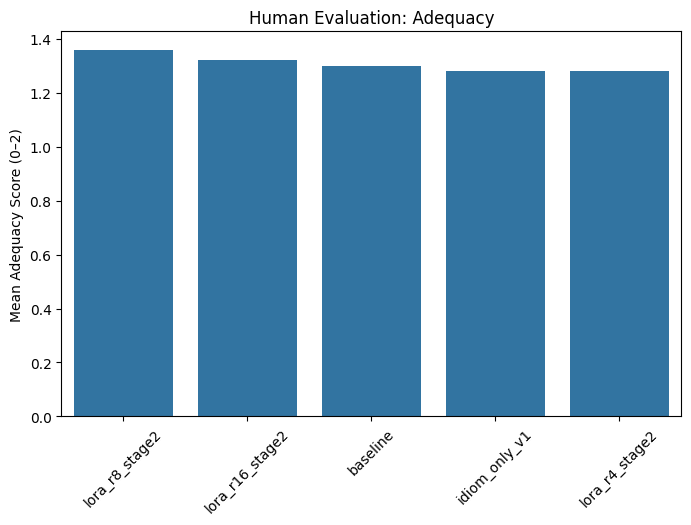

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

df_plot = overall.copy()

sns.barplot(
    data=df_plot,
    x="model",
    y="adequacy_mean"
)

plt.title("Human Evaluation: Adequacy")
plt.ylabel("Mean Adequacy Score (0–2)")
plt.xlabel("")
plt.xticks(rotation=45)
plt.show()

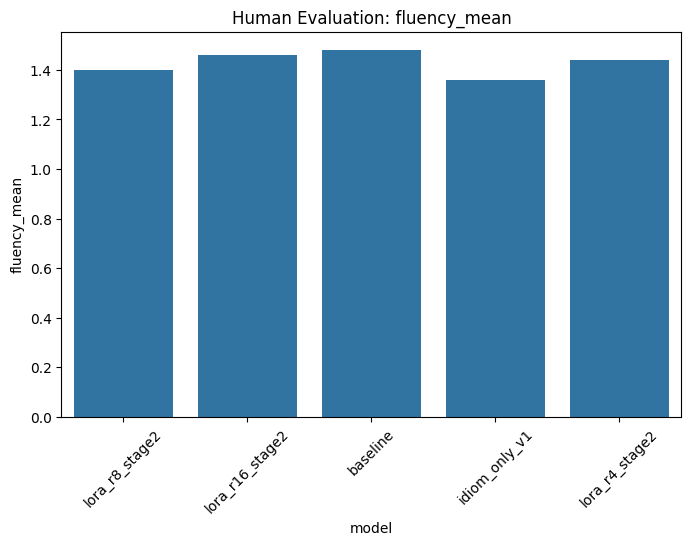

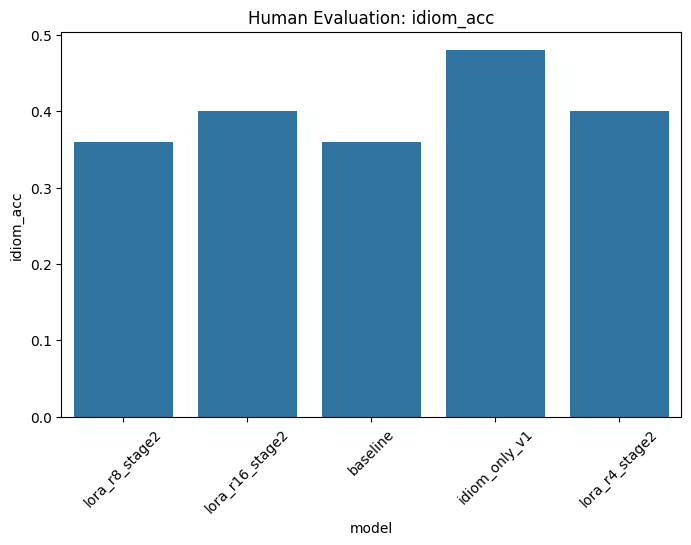

In [14]:
metrics = ["fluency_mean", "idiom_acc"]

for m in metrics:
    plt.figure(figsize=(8,5))
    sns.barplot(data=overall, x="model", y=m)
    plt.title(f"Human Evaluation: {m}")
    plt.xticks(rotation=45)
    plt.show()

**Idiom Correctness**
*   idiom_only_v1 improves idiom correctness the most
*   LoRA models provide moderate gains over
baseline
* r8 shows no improvement

**Adequacy**
* idiom-only model sacrifices meaning accuracy
* LoRA models maintain adequacy equal to baseline.

**Fluency**
* scores are fairly similar
* baseline slightly best
* idiom specialization slightly hurts fluency
* LoRA mostly preserves it

**Over-Idiomatization**
* non existant


**WMT**
* LoRA improves general translation slightly

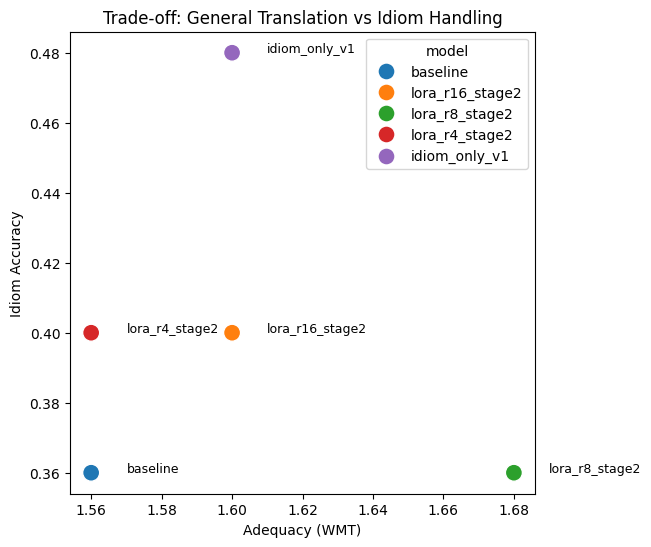

In [15]:
plt.figure(figsize=(6,6))

idioms = summary[summary.group=="idioms_test"]
wmt = summary[summary.group=="wmt_test"]

merged = idioms.merge(
    wmt,
    on="model",
    suffixes=("_idioms","_wmt")
)

sns.scatterplot(
    data=merged,
    x="adequacy_mean_wmt",
    y="idiom_acc_idioms",
    hue="model",
    s=150
)

plt.xlabel("Adequacy (WMT)")
plt.ylabel("Idiom Accuracy")
plt.title("Trade-off: General Translation vs Idiom Handling")

for _, r in merged.iterrows():
    plt.text(
        r["adequacy_mean_wmt"]+0.01,
        r["idiom_acc_idioms"],
        r["model"],
        fontsize=9
    )

plt.show()

### Paired bootstrap CI vs baseline (for idioms)

In [9]:
def paired_bootstrap_ci(df_wide, metric, baseline_model, compare_model, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    ids = df_wide.index.to_numpy()
    diffs = df_wide[compare_model] - df_wide[baseline_model]

    boot = []
    for _ in range(n_boot):
        samp = rng.choice(ids, size=len(ids), replace=True)
        boot.append(diffs.loc[samp].mean())

    boot = np.array(boot)
    return float(diffs.mean()), float(np.percentile(boot, 2.5)), float(np.percentile(boot, 97.5))

def make_wide(long_df, group, metric):
    sub = long_df[long_df["group"] == group].dropna(subset=[metric]).copy()
    wide = sub.pivot(index="example_id", columns="model", values=metric)
    return wide.dropna(axis=1, how="all")

baseline_model = "baseline"  # must match your model name in mapping json

wide_idiom_acc = make_wide(long, "idioms_test", "idiom_correct")
wide_adequacy_idioms = make_wide(long, "idioms_test", "adequacy")

models = [m for m in wide_adequacy_idioms.columns if m != baseline_model]

rows = []
for m in models:
    if m in wide_idiom_acc.columns:
        d, lo, hi = paired_bootstrap_ci(wide_idiom_acc, "idiom_correct", baseline_model, m)
        rows.append({"group":"idioms_test", "metric":"idiom_correct", "model": m, "delta_vs_baseline": d, "ci_low": lo, "ci_high": hi})

    if m in wide_adequacy_idioms.columns:
        d, lo, hi = paired_bootstrap_ci(wide_adequacy_idioms, "adequacy", baseline_model, m)
        rows.append({"group":"idioms_test", "metric":"adequacy", "model": m, "delta_vs_baseline": d, "ci_low": lo, "ci_high": hi})

ci_table = pd.DataFrame(rows).sort_values(["metric","delta_vs_baseline"], ascending=[True, False])
ci_table

,group,metric,model,delta_vs_baseline,ci_low,ci_high
3,idioms_test,adequacy,lora_r16_stage2,0.00,0.00,0.000
7,idioms_test,adequacy,lora_r8_stage2,0.00,0.00,0.000
5,idioms_test,adequacy,lora_r4_stage2,-0.04,-0.12,0.000
1,idioms_test,adequacy,idiom_only_v1,-0.08,-0.32,0.120
0,idioms_test,idiom_correct,idiom_only_v1,0.12,0.00,0.241
2,idioms_test,idiom_correct,lora_r16_stage2,0.04,0.00,0.120
4,idioms_test,idiom_correct,lora_r4_stage2,0.04,0.00,0.120
6,idioms_test,idiom_correct,lora_r8_stage2,0.00,0.00,0.000


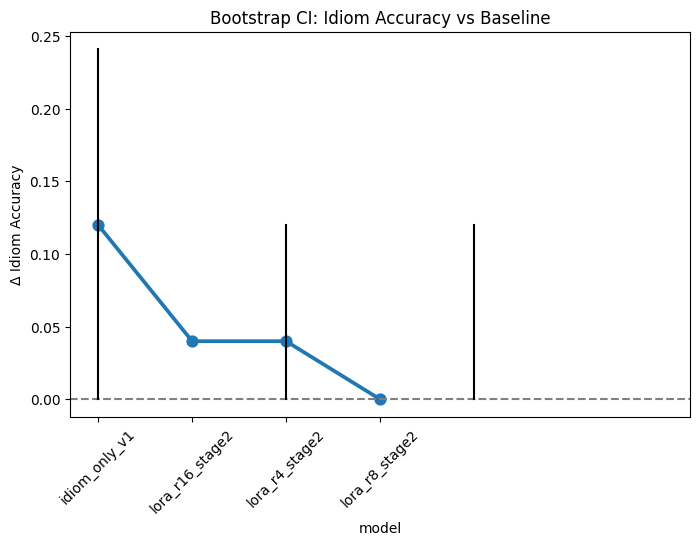

In [17]:
plt.figure(figsize=(8,5))

idiom_ci = ci_table[ci_table.metric=="idiom_correct"]

sns.pointplot(
    data=idiom_ci,
    x="model",
    y="delta_vs_baseline",
)

plt.axhline(0, linestyle="--", color="gray")

for i,row in idiom_ci.iterrows():
    plt.plot(
        [i,i],
        [row.ci_low,row.ci_high],
        color="black"
    )

plt.title("Bootstrap CI: Idiom Accuracy vs Baseline")
plt.ylabel("Δ Idiom Accuracy")
plt.xticks(rotation=45)

plt.show()

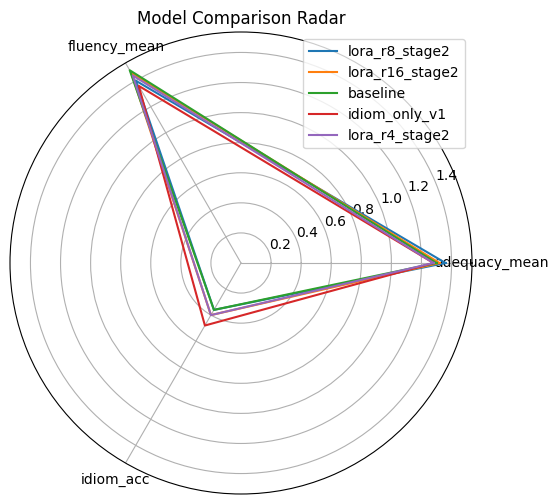

In [18]:
import numpy as np

metrics = ["adequacy_mean","fluency_mean","idiom_acc"]

angles = np.linspace(0,2*np.pi,len(metrics),endpoint=False)
angles = np.concatenate([angles,[angles[0]]])

plt.figure(figsize=(6,6))

for _,row in overall.iterrows():
    vals = row[metrics].tolist()
    vals.append(vals[0])
    plt.polar(angles,vals,label=row["model"])

plt.thetagrids(angles[:-1]*180/np.pi,metrics)
plt.legend()
plt.title("Model Comparison Radar")
plt.show()

Statistical Results
* idiom_only_v1 improves idiom accuracy, but CI [0.00,0.241] inlcudes zero - so not statistically significant --> sample probably too small

### Wins analysis

In [10]:
def pick_winner(df_ex, group):
    # df_ex is rows for a single example_id
    if group == "idioms_test":
        # optional constraint: prefer idiom-correct outputs
        df_ok = df_ex[df_ex["idiom_correct"] == 1]
        if len(df_ok) > 0:
            df_ex = df_ok

    # rank by adequacy then fluency
    df_ex = df_ex.sort_values(["adequacy", "fluency"], ascending=False)
    top = df_ex.iloc[0]
    return top["model"]

winners = (
    long.groupby(["example_id", "group"])
        .apply(lambda g: pick_winner(g, g["group"].iloc[0]))
        .reset_index(name="winner_model")
)

winner_rates = (
    winners.groupby(["group","winner_model"])
           .size()
           .reset_index(name="wins")
)
winner_rates["win_rate"] = winner_rates["wins"] / winner_rates.groupby("group")["wins"].transform("sum")
winner_rates.sort_values(["group","win_rate"], ascending=[True, False])

/tmp/ipykernel_904/1004927758.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pick_winner(g, g["group"].iloc[0]))


,group,winner_model,wins,win_rate
0,idioms_test,baseline,11,0.44
1,idioms_test,idiom_only_v1,7,0.28
3,idioms_test,lora_r4_stage2,3,0.12
2,idioms_test,lora_r16_stage2,2,0.08
4,idioms_test,lora_r8_stage2,2,0.08
6,wmt_test,idiom_only_v1,6,0.24
7,wmt_test,lora_r16_stage2,6,0.24
5,wmt_test,baseline,5,0.20
9,wmt_test,lora_r8_stage2,5,0.20
8,wmt_test,lora_r4_stage2,3,0.12


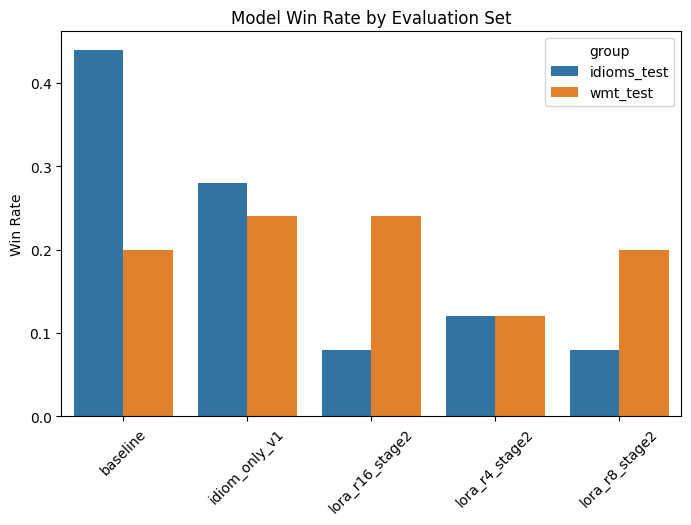

In [16]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=winner_rates,
    x="winner_model",
    y="win_rate",
    hue="group"
)

plt.ylabel("Win Rate")
plt.xlabel("")
plt.title("Model Win Rate by Evaluation Set")

plt.xticks(rotation=45)
plt.show()

**Interpretation**
* Baseline often wins
* Could be explained by the fact that specialized models introduce akward phrasing? Humans favor conservative translations?


**Takeway**
* Idiom-only finetuning yields the largest improvement in idiom correctness
but slightly reduces adequacy.

* LoRA-based adaptation preserves adequacy while providing moderate idiom improvements.


### Export

In [12]:
OUT_DIR = "/content/drive/MyDrive/ds266_idiom_mt/qual_preds/"
import os
os.makedirs(OUT_DIR, exist_ok=True)

summary.to_csv(os.path.join(OUT_DIR, "human_eval_summary_by_split.csv"), index=False)
overall.to_csv(os.path.join(OUT_DIR, "human_eval_summary_overall.csv"), index=False)
ci_table.to_csv(os.path.join(OUT_DIR, "human_eval_bootstrap_ci.csv"), index=False)
winner_rates.to_csv(os.path.join(OUT_DIR, "human_eval_winner_rates.csv"), index=False)

print("Saved to:", OUT_DIR)

Saved to: /content/drive/MyDrive/ds266_idiom_mt/qual_preds/
